In [1]:
!pip install nltk pandas matplotlib seaborn

In [2]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [3]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\drsid\AppData\Roaming\nltk_data...


True

In [4]:
feedback_data = {
    "Intern ID": range(1, 51),
    
    "Feedback": [
        "The internship was an excellent learning experience.",
        "I really enjoyed working with my mentor.",
        "The training sessions were very helpful.",
        "I learned many new skills during the internship.",
        "The team was supportive and friendly.",
        "My mentor provided useful guidance.",
        "The projects helped me improve my practical knowledge.",
        "I am very satisfied with the internship.",
        "The work environment was positive.",
        "The internship exceeded my expectations.",
        
        "The internship was good overall.",
        "I learned useful things from the experience.",
        "The team helped me when I needed support.",
        "The training was useful.",
        "I had a good experience with the company.",
        "The projects were interesting.",
        "My mentor was helpful.",
        "The internship gave me practical experience.",
        "The working environment was comfortable.",
        "I enjoyed completing the assigned tasks.",
        
        "The internship was okay.",
        "The experience was average.",
        "The training was neither good nor bad.",
        "The workload was manageable.",
        "The projects were acceptable.",
        "My mentor provided basic guidance.",
        "The internship met some of my expectations.",
        "The work was sometimes interesting.",
        "The experience was satisfactory.",
        "The overall internship was normal.",
        
        "The training was poorly organized.",
        "I did not receive enough guidance.",
        "The workload was too high.",
        "I was disappointed with the internship.",
        "The tasks were repetitive and boring.",
        "My mentor did not provide enough support.",
        "The communication was poor.",
        "I did not learn as much as expected.",
        "The work environment was stressful.",
        "The internship was not a good experience.",
        
        "The internship schedule was difficult to manage.",
        "I felt unsupported during the projects.",
        "The training materials were confusing.",
        "There were frequent communication problems.",
        "The assigned tasks were unclear.",
        "I had difficulty getting feedback.",
        "The internship did not meet my expectations.",
        "The project deadlines were stressful.",
        "I was unhappy with the overall experience.",
        "The internship needs significant improvement."
    ]
}

df = pd.DataFrame(feedback_data)

df.head()

,Intern ID,Feedback
0,1,The internship was an excellent learning exper...
1,2,I really enjoyed working with my mentor.
2,3,The training sessions were very helpful.
3,4,I learned many new skills during the internship.
4,5,The team was supportive and friendly.


In [5]:
df.shape

(50, 2)

In [6]:
df.columns

Index(['Intern ID', 'Feedback'], dtype='str')

In [7]:
df.isnull().sum()

Intern ID    0
Feedback     0
dtype: int64

In [8]:
sia = SentimentIntensityAnalyzer()

In [9]:
df["Sentiment Score"] = df["Feedback"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

df.head()

,Intern ID,Feedback,Sentiment Score
0,1,The internship was an excellent learning exper...,0.5719
1,2,I really enjoyed working with my mentor.,0.5563
2,3,The training sessions were very helpful.,0.4754
3,4,I learned many new skills during the internship.,0.0000
4,5,The team was supportive and friendly.,0.6597


In [10]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Sentiment Score"].apply(classify_sentiment)

df.head()

,Intern ID,Feedback,Sentiment Score,Sentiment
0,1,The internship was an excellent learning exper...,0.5719,Positive
1,2,I really enjoyed working with my mentor.,0.5563,Positive
2,3,The training sessions were very helpful.,0.4754,Positive
3,4,I learned many new skills during the internship.,0.0000,Neutral
4,5,The team was supportive and friendly.,0.6597,Positive


In [11]:
sentiment_counts = df["Sentiment"].value_counts()

sentiment_counts

Sentiment
Positive    22
Negative    15
Neutral     13
Name: count, dtype: int64

In [12]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_percentage

Sentiment
Positive    44.0
Negative    30.0
Neutral     26.0
Name: proportion, dtype: float64

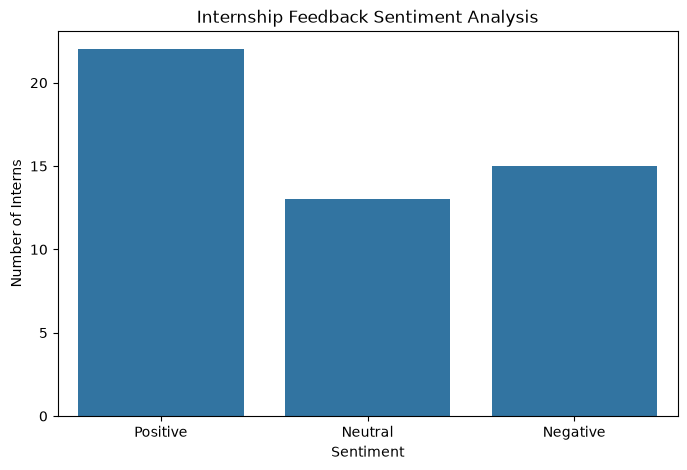

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Internship Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Interns")

plt.show()

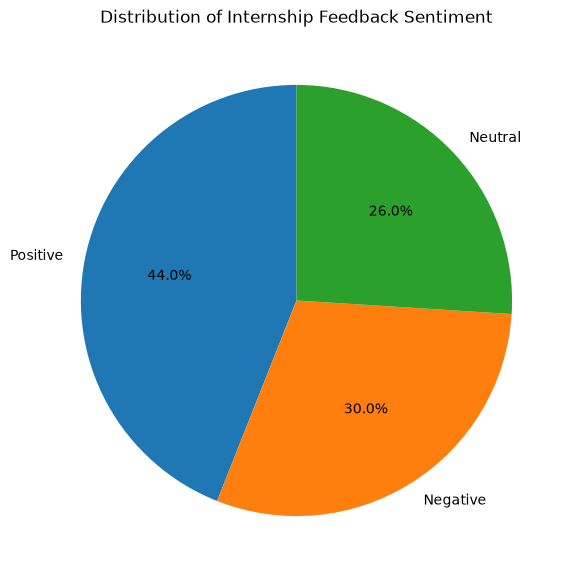

In [14]:
plt.figure(figsize=(7, 7))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Internship Feedback Sentiment")
plt.ylabel("")

plt.show()

In [15]:
positive_feedback = df[df["Sentiment"] == "Positive"]

positive_feedback[["Intern ID", "Feedback"]].head(10)

,Intern ID,Feedback
0,1,The internship was an excellent learning exper...
1,2,I really enjoyed working with my mentor.
2,3,The training sessions were very helpful.
4,5,The team was supportive and friendly.
5,6,My mentor provided useful guidance.
6,7,The projects helped me improve my practical kn...
7,8,I am very satisfied with the internship.
8,9,The work environment was positive.
10,11,The internship was good overall.
11,12,I learned useful things from the experience.


In [16]:
negative_feedback = df[df["Sentiment"] == "Negative"]

negative_feedback[["Intern ID", "Feedback"]].head(10)

,Intern ID,Feedback
22,23,The training was neither good nor bad.
33,34,I was disappointed with the internship.
34,35,The tasks were repetitive and boring.
35,36,My mentor did not provide enough support.
36,37,The communication was poor.
38,39,The work environment was stressful.
39,40,The internship was not a good experience.
40,41,The internship schedule was difficult to manage.
41,42,I felt unsupported during the projects.
42,43,The training materials were confusing.


In [17]:
neutral_feedback = df[df["Sentiment"] == "Neutral"]

neutral_feedback[["Intern ID", "Feedback"]].head(10)

,Intern ID,Feedback
3,4,I learned many new skills during the internship.
9,10,The internship exceeded my expectations.
17,18,The internship gave me practical experience.
21,22,The experience was average.
23,24,The workload was manageable.
25,26,My mentor provided basic guidance.
26,27,The internship met some of my expectations.
29,30,The overall internship was normal.
30,31,The training was poorly organized.
31,32,I did not receive enough guidance.


In [18]:
df.to_csv(
    "Internship_Feedback_Sentiment_Analysis.csv",
    index=False
)

In [19]:
df.head(10)

,Intern ID,Feedback,Sentiment Score,Sentiment
0,1,The internship was an excellent learning exper...,0.5719,Positive
1,2,I really enjoyed working with my mentor.,0.5563,Positive
2,3,The training sessions were very helpful.,0.4754,Positive
3,4,I learned many new skills during the internship.,0.0000,Neutral
4,5,The team was supportive and friendly.,0.6597,Positive
5,6,My mentor provided useful guidance.,0.4404,Positive
6,7,The projects helped me improve my practical kn...,0.4404,Positive
7,8,I am very satisfied with the internship.,0.4754,Positive
8,9,The work environment was positive.,0.5574,Positive
9,10,The internship exceeded my expectations.,0.0000,Neutral


In [20]:
df.tail(10)

,Intern ID,Feedback,Sentiment Score,Sentiment
40,41,The internship schedule was difficult to manage.,-0.3612,Negative
41,42,I felt unsupported during the projects.,-0.4019,Negative
42,43,The training materials were confusing.,-0.2263,Negative
43,44,There were frequent communication problems.,-0.4019,Negative
44,45,The assigned tasks were unclear.,-0.2500,Negative
45,46,I had difficulty getting feedback.,-0.3400,Negative
46,47,The internship did not meet my expectations.,0.0000,Neutral
47,48,The project deadlines were stressful.,-0.5106,Negative
48,49,I was unhappy with the overall experience.,-0.4215,Negative
49,50,The internship needs significant improvement.,0.5859,Positive


In [21]:
df

,Intern ID,Feedback,Sentiment Score,Sentiment
0,1,The internship was an excellent learning exper...,0.5719,Positive
1,2,I really enjoyed working with my mentor.,0.5563,Positive
2,3,The training sessions were very helpful.,0.4754,Positive
3,4,I learned many new skills during the internship.,0.0000,Neutral
4,5,The team was supportive and friendly.,0.6597,Positive
5,6,My mentor provided useful guidance.,0.4404,Positive
6,7,The projects helped me improve my practical kn...,0.4404,Positive
7,8,I am very satisfied with the internship.,0.4754,Positive
8,9,The work environment was positive.,0.5574,Positive
9,10,The internship exceeded my expectations.,0.0000,Neutral


In [22]:
total_feedback = len(df)

positive_count = (df["Sentiment"] == "Positive").sum()
neutral_count = (df["Sentiment"] == "Neutral").sum()
negative_count = (df["Sentiment"] == "Negative").sum()

print("Total Feedback:", total_feedback)
print("Positive Feedback:", positive_count)
print("Neutral Feedback:", neutral_count)
print("Negative Feedback:", negative_count)

print("\nPositive Percentage:",
      round(positive_count / total_feedback * 100, 2), "%")

print("Neutral Percentage:",
      round(neutral_count / total_feedback * 100, 2), "%")

print("Negative Percentage:",
      round(negative_count / total_feedback * 100, 2), "%")

Total Feedback: 50
Positive Feedback: 22
Neutral Feedback: 13
Negative Feedback: 15

Positive Percentage: 44.0 %
Neutral Percentage: 26.0 %
Negative Percentage: 30.0 %
